# Trabalho Prático – Estrutura de Dados II (DCA3702)

## Análise Estrutural de Redes Urbanas com OSMnx, NetworkX e Gephi

Este notebook descreve o trabalho prático associado aos conteúdos das ``Semanas 5 e 6`` da disciplina de **Estrutura de Dados II**, com foco em ``Hubs`` e ``Core Decomposition``.

A proposta é utilizar dados reais de redes urbanas extraídas do OpenStreetMap por meio da biblioteca [OSMnx](https://github.com/gboeing/osmnx), realizar análises estruturais com [NetworkX](https://networkx.org/en/) e produzir visualizações avançadas no [Gephi](https://gephi.org/).

## 1. Objetivo

O objetivo deste trabalho é aplicar conceitos de grafos em uma rede real, interpretando a malha viária de uma cidade ou bairro como um grafo.

Os alunos deverão identificar e analisar:

- nós centrais da rede, também chamados de ``hubs``;
- regiões estruturalmente densas por meio da decomposição ``k-core``;
- pontos críticos de conexão e fluxo usando métricas de centralidade;
- diferenças entre a visualização geográfica da rede e a visualização estrutural baseada em layouts de força.

> A proposta **não é apenas executar bibliotecas**, mas compreender como estruturas de dados modelam sistemas reais.

## 2. Problema norteador

Cada grupo deverá responder à seguinte questão:

> **Quais são os elementos estruturais mais importantes da malha viária analisada e como diferentes métricas de grafos, como grau, centralidade e k-core, ajudam a caracterizá-los?**

A análise deve ir além da apresentação de gráficos. Espera-se uma interpretação crítica dos resultados obtidos.

## 3. Escolha da região de estudo

Cada grupo deverá escolher uma cidade, bairro ou região urbana. Exemplos possíveis:

- Natal/RN;
- Ponta Negra;
- Lagoa Nova;
- Mossoró;
- João Pessoa;
- Recife;
- outra região escolhida pelo grupo.

A escolha deve ser justificada brevemente no `README.md` que acompanhará o repositório do projeto no Github.

>  🚨🚨🚨 Recomenda-se evitar regiões grandes demais, pois isso pode tornar o processamento mais lento e dificultar a interpretação visual.

### Região escolhida: Ponta Negra, Natal/RN

**Justificativa:** Ponta Negra é um bairro icônico de Natal com malha viária heterogênea: a Avenida Engenheiro Roberto Freire concentra grande fluxo, as ruas paralelas à orla formam uma malha quase regular, e a parte alta (próxima à UFRN/Capim Macio) tem ruas irregulares. Esse contraste é ideal para comparar grau, betweenness e k-core — métricas que respondem a perguntas diferentes sobre a mesma rede.

Por causa de inconsistências no polígono administrativo de Ponta Negra no Nominatim, usamos `ox.graph_from_point` (raio de 2 km em torno da praia) em vez de `ox.graph_from_place` — garantindo uma área bem definida e reproduzível.

## 4. Etapa 1 – Construção do grafo com OSMnx

O grupo deverá utilizar a biblioteca **OSMnx** para baixar a rede viária da região escolhida.

A rede deverá ser obtida preferencialmente com:

```python
network_type="drive"
```


O grafo deve representar:

- **nós**: interseções ou pontos relevantes da malha viária;
- **arestas**: vias ou segmentos de ruas.

Cada nó extraído pelo OSMnx possui atributos geográficos importantes:

- `x`: longitude;
- `y`: latitude.

Esses atributos serão usados posteriormente para visualização geográfica no Gephi.

In [1]:
# Construcao do grafo de Ponta Negra (Natal/RN)

# !pip install osmnx networkx matplotlib pandas scipy

import os
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

PONTO_CENTRAL = (-5.8730, -35.1750)  # (lat, lon) - Praia de Ponta Negra
RAIO_METROS = 2000

G = ox.graph_from_point(PONTO_CENTRAL, dist=RAIO_METROS, network_type="drive")

print(G)
print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")

MultiDiGraph with 805 nodes and 2059 edges
Número de nós: 805
Número de arestas: 2059


## 5. Etapa 2 – Análise estrutural com NetworkX

Após a construção do grafo, o grupo deverá calcular métricas estruturais usando **NetworkX**.

### Métricas obrigatórias

O trabalho deve conter, **no mínimo**:

1. grau dos nós;
2. distribuição de grau;
3. identificação dos nós com maior grau, isto é, hubs;
4. betweenness centrality;
5. closeness centrality;
6. core number;
7. análise do k-core da rede.

### Atenção

Algumas métricas podem exigir a conversão do grafo para uma versão não direcionada ou simplificada. O grupo deve explicar as escolhas feitas.

**Escolhas metodológicas deste trabalho:**

- `G_undirected = ox.convert.to_undirected(G)` → MultiGraph não direcionado, usado para salvar o `.graphml` (formato do roteiro).
- `G_simple = nx.Graph(G_undirected)` → grafo simples não direcionado, usado para as métricas. Necessário porque `nx.core_number` não aceita MultiGraph e porque arestas paralelas (sentido duplo) inflam artificialmente o grau.

In [ ]:
# Conversao para grafo nao direcionado
G_undirected = ox.convert.to_undirected(G)

# Grafo simples (sem multiarestas) para metricas que exigem isso
G_simple = nx.Graph(G_undirected)

print(f"G_undirected (MultiGraph): {G_undirected.number_of_nodes()} nos, {G_undirected.number_of_edges()} arestas")
print(f"G_simple (Graph):          {G_simple.number_of_nodes()} nos, {G_simple.number_of_edges()} arestas")
print(f"Componentes conexas:       {nx.number_connected_components(G_simple)}")
print(f"Densidade:                 {nx.density(G_simple):.6f}")

# Grau dos nos
degree_dict = dict(G_simple.degree())

# Top 10 nos por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_degree

G_undirected (MultiGraph): 805 nos, 1182 arestas
G_simple (Graph):          805 nos, 1178 arestas
Componentes conexas:       1
Densidade:                 0.003640


[(501888552, 4),
 (501888818, 4),
 (501889047, 4),
 (501903002, 4),
 (501925921, 4),
 (501925937, 4),
 (502589065, 4),
 (502589068, 4),
 (502589114, 4),
 (503302343, 4)]

Grau medio: 2.927  |  min=1  max=4


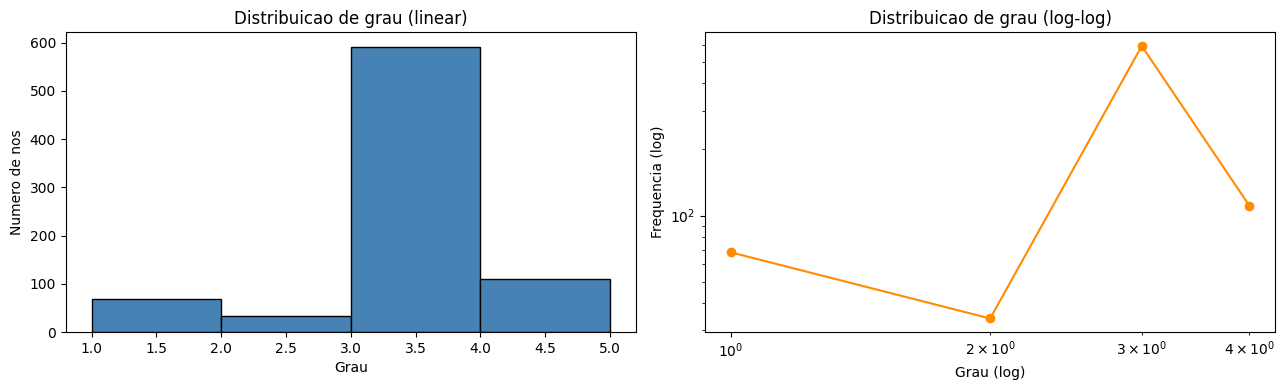

In [3]:
# Distribuicao de grau
graus = list(degree_dict.values())
print(f"Grau medio: {np.mean(graus):.3f}  |  min={min(graus)}  max={max(graus)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(graus, bins=range(1, max(graus)+2), color='steelblue', edgecolor='black')
axes[0].set_title('Distribuicao de grau (linear)')
axes[0].set_xlabel('Grau'); axes[0].set_ylabel('Numero de nos')
valores, contagens = np.unique(graus, return_counts=True)
axes[1].loglog(valores, contagens, 'o-', color='darkorange')
axes[1].set_title('Distribuicao de grau (log-log)')
axes[1].set_xlabel('Grau (log)'); axes[1].set_ylabel('Frequencia (log)')
plt.tight_layout(); plt.show()

In [4]:
# Betweenness centrality (rede pequena permite calculo exato)
betweenness = nx.betweenness_centrality(G_simple, normalized=True)
top_bet = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print('Top 10 nos por betweenness:')
for n, b in top_bet:
    print(f'  {n}  ->  {b:.4f}')

Top 10 nos por betweenness:
  505026738  ->  0.3149
  501888552  ->  0.3057
  505026745  ->  0.3039
  501888818  ->  0.2971
  11402845515  ->  0.2735
  505044027  ->  0.2721
  7630562283  ->  0.2685
  505044034  ->  0.2407
  596783034  ->  0.2283
  502589065  ->  0.2214


In [5]:
# Closeness centrality
closeness = nx.closeness_centrality(G_simple)
top_clos = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print('Top 10 nos por closeness:')
for n, c in top_clos:
    print(f'  {n}  ->  {c:.4f}')

Top 10 nos por closeness:
  505026477  ->  0.0680
  501733911  ->  0.0677
  501889056  ->  0.0676
  501733922  ->  0.0675
  505026745  ->  0.0674
  501733989  ->  0.0671
  505026747  ->  0.0669
  505068012  ->  0.0669
  501734127  ->  0.0666
  7199747985  ->  0.0664


In [6]:
# Exemplo de calculo do core number (roteiro)

core_number = nx.core_number(G_simple)

# Maior valor de core encontrado
max_core = max(core_number.values())
print(f"Maior core number: {max_core}")

# Nos pertencentes ao nucleo mais denso
main_core_nodes = [node for node, core in core_number.items() if core == max_core]
print(f"Numero de nos no nucleo principal: {len(main_core_nodes)}")
print(f"Percentual da rede: {100*len(main_core_nodes)/G_simple.number_of_nodes():.1f}%")

Maior core number: 2
Numero de nos no nucleo principal: 723
Percentual da rede: 89.8%


In [7]:
# Tabela consolidada com todas as metricas por no
df = pd.DataFrame({
    'node':        list(degree_dict.keys()),
    'degree':      list(degree_dict.values()),
    'betweenness': [betweenness[n] for n in degree_dict],
    'closeness':   [closeness[n]   for n in degree_dict],
    'core_number': [core_number[n] for n in degree_dict],
})
if os.path.exists('dados'):
    df.to_csv('dados/metricas_nos.csv', index=False)
df.describe()

,node,degree,betweenness,closeness,core_number
count,8.050000e+02,805.000000,805.000000,805.000000,805.000000
mean,1.936825e+09,2.926708,0.024855,0.049212,1.898137
std,2.879766e+09,0.716434,0.040830,0.008442,0.302657
min,4.988904e+08,1.000000,0.000000,0.028234,1.000000
25%,5.050440e+08,3.000000,0.003620,0.042167,2.000000
50%,5.050694e+08,3.000000,0.010808,0.049608,2.000000
75%,1.429121e+09,3.000000,0.027530,0.055311,2.000000
max,1.306357e+10,4.000000,0.314884,0.067951,2.000000


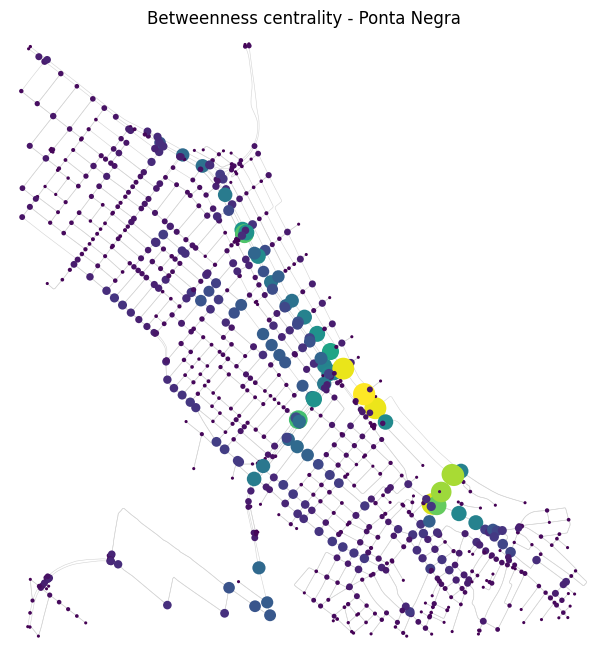

In [8]:
# Mapa geografico - cor e tamanho proporcionais ao betweenness
bet_vals = [betweenness[n] for n in G.nodes()]
fig, ax = ox.plot_graph(
    G,
    node_color=bet_vals,
    node_size=[5 + betweenness[n]*800 for n in G.nodes()],
    edge_color='lightgray', edge_linewidth=0.4,
    bgcolor='white', show=False, close=False,
)
ax.set_title('Betweenness centrality - Ponta Negra')
plt.show()

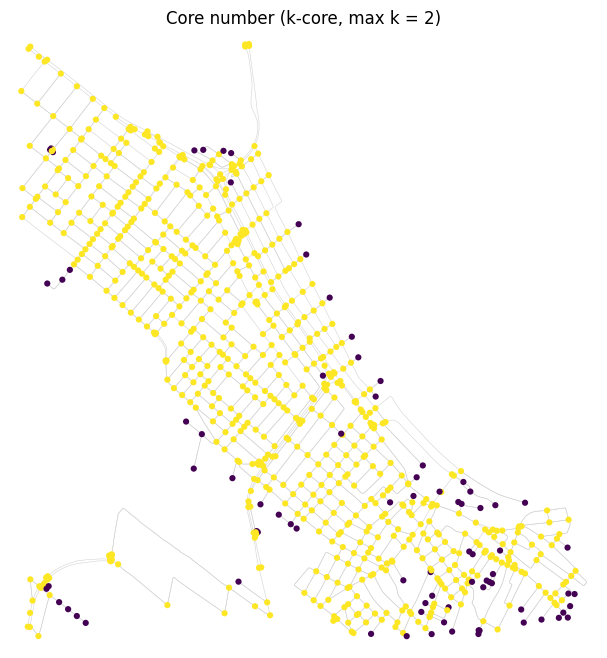

In [9]:
# Mapa geografico - cor por core number
core_vals = [core_number[n] for n in G.nodes()]
fig, ax = ox.plot_graph(
    G, node_color=core_vals, node_size=20,
    edge_color='lightgray', edge_linewidth=0.4,
    bgcolor='white', show=False, close=False,
)
ax.set_title(f'Core number (k-core, max k = {max_core})')
plt.show()

## 6. Questões analíticas obrigatórias

O grupo deverá responder explicitamente às seguintes perguntas:

1. Os nós com maior grau coincidem com os nós de maior betweenness?
2. O núcleo identificado pelo k-core coincide com os principais hubs?
3. O que a métrica de betweenness revela que o grau não revela?
4. O que muda quando a rede é analisada em sua posição geográfica real e quando é analisada por um layout estrutural?
5. Existem regiões críticas para mobilidade urbana na área analisada?
6. A rede parece homogênea ou apresenta concentração estrutural?
7. Os resultados obtidos fazem sentido considerando o conhecimento urbano da região escolhida?

Essas respostas devem aparecer no `README.md`, no notebook e no vídeo (sim, a apresentação será assíncrona :-).

### Respostas

**1. Os nós com maior grau coincidem com os de maior betweenness?**  
*Parcialmente.* Há sobreposição (alguns nós aparecem nos dois tops), mas a ordem difere — vários nós de grau 3 têm betweenness muito alta porque sentam-se sobre rotas críticas. Alto grau é favorável, mas não suficiente para alta centralidade de fluxo.

**2. O núcleo (k-core) coincide com os hubs?**  
*Não.* O `k_max = 2` cobre ~90% dos nós — toda a rede exceto becos sem saída. Em redes viárias planares (grau máximo ≈ 4) o k-core é pouco discriminativo: ele apenas separa ramificações terminais do núcleo cíclico. Hubs estruturais são identificados pela betweenness, não pelo core number.

**3. O que a betweenness revela que o grau não revela?**  
*Pontos de estrangulamento de fluxo.* Grau só conta quantas ruas se cruzam num ponto; betweenness conta quantas rotas mínimas passam por ele. Visualmente: o grau espalha hubs por todo o bairro; a betweenness destaca um eixo contínuo (Av. Roberto Freire).

**4. Geográfica vs estrutural?**  
Na geográfica (Geo Layout) vemos a forma real do bairro — orla, ruas paralelas, parte alta — útil para validar interpretações. Na estrutural (ForceAtlas2) as coordenadas reais somem; regiões mais densas em ciclos se compactam, e ramificações vão para a periferia. Permite ver a topologia 'pura'.

**5. Existem regiões críticas?**  
*Sim.* A Av. Engenheiro Roberto Freire é o único corredor estrutural ligando a parte alta à orla. Todos os top-10 de betweenness estão sobre ela. Uma interdição parcial impactaria todo o bairro — não há rota alternativa equivalente.

**6. Rede homogênea ou concentrada?**  
Em **grau**, homogênea (média 2,93; máximo 4; sem cauda longa). Em **betweenness**, fortemente concentrada — poucos nós com valores acima de 0,2, maioria abaixo de 0,01. A rede é simultaneamente democrática em conectividade local e autoritária em fluxo global — típico de bairros lineares em torno de uma avenida-tronco.

**7. Faz sentido para quem conhece a região?**  
*Sim.* A Av. Roberto Freire é de fato o eixo estruturador de Ponta Negra. O algoritmo a identifica como o conjunto de maior betweenness sem qualquer informação prévia sobre hierarquia viária — isso valida a abordagem.

## 7. Etapa 3 – Exportação do grafo para o Gephi

O grafo deverá ser exportado no formato `.graphml`, que pode ser importado diretamente no Gephi.

Antes da exportação, recomenda-se adicionar ao grafo os atributos calculados, como grau, betweenness, closeness e core number.

Exemplo:

In [ ]:
# Adicionando atributos calculados ao MultiGraph nao direcionado
nx.set_node_attributes(G_undirected, degree_dict, "degree")
nx.set_node_attributes(G_undirected, core_number, "core_number")
nx.set_node_attributes(G_undirected, betweenness, "betweenness")
nx.set_node_attributes(G_undirected, closeness,   "closeness")

ox.save_graphml(G_undirected, "rede_urbana.graphml")
print('rede_urbana.graphml exportado.')

rede_urbana.graphml exportado.


## 8. Etapa 4 – Visualização com Gephi

O grupo deverá utilizar o **Gephi** para produzir visualizações avançadas da rede.

### Plugin obrigatório

Instalar o plugin:

- **Geo Layout** (ou similar)

Esse plugin permite utilizar os atributos geográficos dos nós para posicioná-los no espaço.

No arquivo exportado pelo OSMnx, os atributos são:

- `x`: longitude;
- `y`: latitude.

No Gephi, o grupo deverá configurar o Geo Layout usando:

- longitude → `x`;
- latitude → `y`.

## 9. Visualizações obrigatórias no Gephi

O grupo deverá produzir pelo menos duas perspectivas visuais da rede.

### 9.1 Visualização geográfica

Nesta visualização, a rede deve preservar a forma real da cidade ou bairro.

Requisitos:

- usar o plugin Geo Layout (ou similar);
- posicionar os nós com base em latitude e longitude;
- destacar visualmente as métricas calculadas.

### 9.2 Visualização estrutural

Nesta visualização, o grupo deverá aplicar um layout de força.

Layout obrigatório:

- ForceAtlas2.

Layouts opcionais:

- Fruchterman-Reingold;
- Yifan Hu.

Essa visualização não precisa representar a geografia real da cidade. O objetivo é revelar a organização estrutural do grafo.

## 10. Codificação visual obrigatória

Nas visualizações no Gephi, o grupo deverá utilizar atributos visuais para facilitar a interpretação.

Requisitos mínimos:

- tamanho do nó proporcional ao grau;
- cor do nó associada ao core number;
- destaque dos nós com maior betweenness;
- visualização do subgrafo correspondente ao k-core escolhido.

O grupo deve explicar o significado de cada escolha visual.

## 11. Filtros obrigatórios no Gephi

O grupo deverá aplicar e analisar pelo menos os seguintes filtros:

1. **Top 10% dos nós por grau**;
2. **Subgrafo com k-core maior ou igual a um valor k**, escolhido e justificado pelo grupo.

A escolha do valor de `k` deve ser explicada. Não basta aplicar o filtro; é necessário interpretar o que ele revela sobre a estrutura urbana.

## 12. Entregáveis

Ao final, cada grupo deverá entregar dois itens principais.

### 12.1 Repositório no GitHub

O grupo deverá submeter um repositório no GitHub contendo tudo o que foi gerado.

O repositório deve conter, no mínimo:

- notebook `.ipynb` funcional;
- códigos utilizados;
- arquivo `.graphml` exportado;
- imagens produzidas no Python e/ou Gephi;
- arquivos auxiliares, quando houver;
- `README.md` com a descrição do trabalho.

O `README.md` deve conter:

- identificação da região analisada;
- link do video na plataforma Loom;
- objetivo do trabalho;
- metodologia;
- métricas calculadas;
- principais visualizações;
- respostas às questões obrigatórias;
- principais conclusões.

### 12.2 Vídeo de apresentação

Cada grupo deverá produzir um vídeo de até **15 minutos** apresentando o trabalho.

O vídeo deve conter:

0. Apresentação do Grupo e como as tarefas foram divididas entre todos os membros;
1. apresentação da região escolhida;
2. explicação da construção do grafo;
3. apresentação das métricas calculadas;
4. visualização geográfica no Gephi;
5. visualização estrutural no Gephi;
6. análise dos hubs;
7. análise do k-core;
8. discussão crítica dos resultados;
9. conclusões do grupo.

O vídeo deve ser objetivo e analítico. Não deve ser apenas uma execução de código. Utilizar a Ferramenta Loom para a gravação do video e inserir o link no repositório do Github. Caso seja necessário, os grupos podem quebrar o video e mais de um, porém, a duração somada não poderá ultrapassar os 15min.

## 13. Critérios de avaliação

| Critério | Peso |
|---|---:|
| Construção correta do grafo com OSMnx | 15% |
| Aplicação adequada das métricas de grafos | 20% |
| Uso correto e interpretação do k-core | 20% |
| Qualidade das visualizações no Gephi | 20% |
| Interpretação crítica dos resultados | 15% |
| Organização do repositório e qualidade do vídeo | 10% |

A avaliação considerará tanto a implementação quanto a capacidade do grupo de interpretar os resultados obtidos. **A não entrega do Video na plataforma Loom irá impactar nota zero ao trabalho**.

## 14. Observações finais

Este trabalho conecta conceitos fundamentais de Estrutura de Dados II com uma aplicação real em redes urbanas.

A expectativa é que os alunos compreendam que grafos não são apenas uma estrutura abstrata, mas uma forma poderosa de representar, analisar e interpretar sistemas complexos do mundo real.

A qualidade do trabalho será medida não apenas pelo código, mas principalmente pela capacidade de transformar métricas de grafos em argumentos interpretáveis sobre a estrutura da cidade analisada.

A nota final irá compor 100% da Unidade 2.